## aLIGO Noise Budgets
Plots adapted from: https://dcc.ligo.org/public/0148/P1800001/002/Schreiber%20thesis%20e-print.pdf

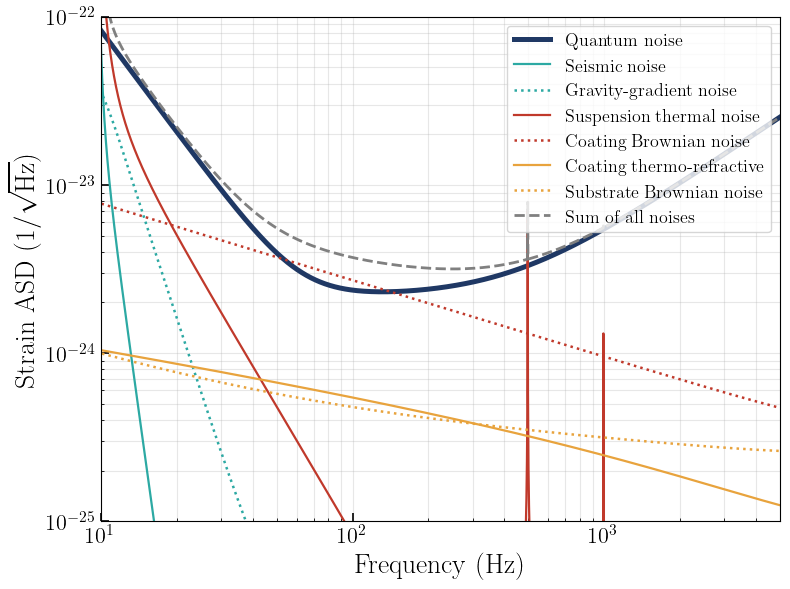

Saved: /Users/asca/PhD/photodiodes/code/gwinc/fig/gwinc_noise_budget_aLIGO.png


In [2]:
import os
import gwinc
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
path = "/Users/asca/PhD/photodiodes/code/gwinc/"
fig_dir = os.path.join(path, "fig")
os.makedirs(fig_dir, exist_ok=True)
# aLIGO current-gen GWO
budget = gwinc.load_budget('aLIGO')
trace = budget.run()
freq = trace.freq
noise_style = {
    'Quantum':            dict(label=r'Quantum noise',            color='#1f3864', ls='-', lw=3.6),
    'Seismic':            dict(label=r'Seismic noise',             color='#2ca9a3', ls='-', lw=1.6),
    'Newtonian':          dict(label=r'Gravity-gradient noise',    color='#2ca9a3', ls=':', lw=1.8),
    'SuspensionThermal':  dict(label=r'Suspension thermal noise',  color='#c0392b', ls='-', lw=1.6),
    'CoatingBrownian':    dict(label=r'Coating Brownian noise',    color='#c0392b', ls=':', lw=1.8),
    'CoatingThermoOptic': dict(label=r'Coating thermo-refractive', color='#e8a33d', ls='-', lw=1.6),
    'SubstrateBrownian':  dict(label=r'Substrate Brownian noise',  color='#e8a33d', ls=':', lw=1.8),
}

fig, ax = plt.subplots(figsize=(8, 6))
available_keys = list(trace.keys())
for key, style in noise_style.items():
    if key in available_keys:
        sub = trace[key]
        ax.loglog(freq, sub.asd, label=style['label'], color=style['color'], linestyle=style['ls'], linewidth=style['lw'])
ax.loglog(freq, trace.asd, label=r'Sum of all noises', color='gray', linestyle='--', linewidth=2)
ax.set_xlabel(r'Frequency (Hz)', fontsize=20)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=20)
ax.set_xlim(10, 5000)
ax.set_ylim(1e-25, 1e-22)
ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2, direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper right', fontsize=13, frameon=True)
fig.tight_layout()
save_path = os.path.join(fig_dir, "gwinc_noise_budget_aLIGO.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

Shading regions where classical noise sources are still dominant (seismic and coating Brownian contributions)

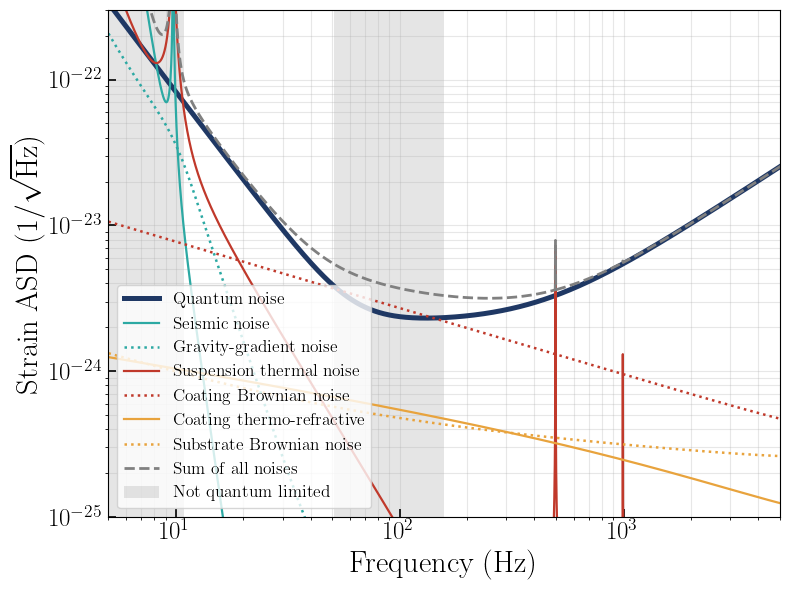

    5.0 -    10.8 Hz : Seismic
   50.7 -   158.5 Hz : CoatingBrownian


In [3]:
import numpy as np
from matplotlib.patches import Patch

def classical_bands(trace, thresh=0.5, min_ratio=1.03):
    """Frequency bands where quantum noise contributes less than `thresh`
    of the total noise POWER, i.e. where aLIGO is not quantum limited.
    min_ratio drops slivers (violin modes) narrower than that factor in f."""
    f = trace.freq
    mask = trace['Quantum'].asd**2 < thresh * trace.asd**2
    idx = np.where(mask)[0]
    if not len(idx):
        return []
    segs = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    return [(f[s[0]], f[s[-1]]) for s in segs if f[s[-1]] / f[s[0]] >= min_ratio]

def dominant(trace, lo, hi):
    """Which classical noise wins in a band (median PSD over the band)."""
    sel = (trace.freq >= lo) & (trace.freq <= hi)
    return max((np.median(trace[k].asd[sel]**2), k)
               for k in trace.keys() if k != 'Quantum')[1]

fig, ax = plt.subplots(figsize=(8, 6))

# --- gray shading, drawn first so it sits under the curves ---
bands = classical_bands(trace)
for lo, hi in bands:
    ax.axvspan(lo, hi, color='0.55', alpha=0.22, lw=0, zorder=0)

for key, style in noise_style.items():
    if key in trace.keys():
        ax.loglog(freq, trace[key].asd, label=style['label'],
                  color=style['color'], linestyle=style['ls'], linewidth=style['lw'])
ax.loglog(freq, trace.asd, label=r'Sum of all noises', color='gray', ls='--', lw=2)

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='0.55', alpha=0.22))
labels.append(r'Not quantum limited')
#ax.legend(handles, labels, loc='lower left', fontsize=10.5, frameon=True)
ax.legend(handles, labels, loc='lower left', fontsize=12.5, frameon=True)
ax.set_xlabel(r'Frequency (Hz)', fontsize=22)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.2, direction='in')

#ax.set_xlabel(r'Frequency (Hz)', fontsize=20)
#ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=20)
ax.set_xlim(5, 5000)
ax.set_ylim(1e-25, 3e-22)
#ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2, direction='in')
#ax.tick_params(axis='both', which='minor', direction='in')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "gwinc_noise_budget_aLIGO_shaded.png"),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

for lo, hi in bands:
    print(f"{lo:7.1f} - {hi:7.1f} Hz : {dominant(trace, lo, hi)}")

Squeezing is implemented in aLIGO, however the aLIGO .yaml doesn't have a squeezer.

Making shading regions explicit

keys     : ['Quantum', 'Seismic', 'Newtonian', 'SuspensionThermal', 'CoatingBrownian', 'CoatingThermoOptic', 'SubstrateBrownian', 'SubstrateThermoElastic', 'ResidualGas']
unstyled : none
closure  : max|sum/total-1| = 6.7e-16
    5.0 -    10.8 Hz | Seismic 48%,  SuspensionThermal 15%,  Quantum 8%,  Newtonian 2%,  CoatingBrownian 0%
   50.7 -   158.5 Hz | CoatingBrownian 55%,  Quantum 40%,  CoatingThermoOptic 2%,  SubstrateBrownian 2%,  ResidualGas 1%


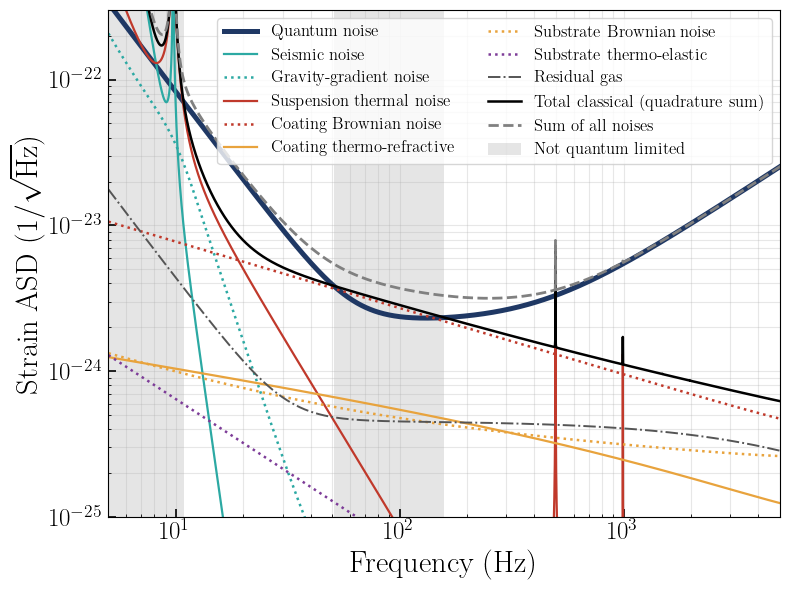

In [4]:
import numpy as np
from matplotlib.patches import Patch

# extend your style dict; extras get a visible fallback rather than being dropped
noise_style_ext = dict(noise_style)
noise_style_ext.update({
    'ITMThermoRefractive':     dict(label=r'ITM thermo-refractive',     color='#7d3c98', ls='-',  lw=1.6),
    'SubstrateThermoElastic':  dict(label=r'Substrate thermo-elastic',  color='#7d3c98', ls=':',  lw=1.8),
    'ResidualGas':             dict(label=r'Residual gas',              color='#555555', ls='-.', lw=1.4),
    'ExcessGas':               dict(label=r'Residual gas',              color='#555555', ls='-.', lw=1.4),
})
QK = 'Quantum' if 'Quantum' in trace.keys() else 'QuantumVacuum'

def audit(trace, qkey=QK):
    keys = list(trace.keys())
    unstyled = [k for k in keys if k not in noise_style_ext]
    closure = np.max(np.abs(sum(trace[k].asd**2 for k in keys) / trace.asd**2 - 1))
    print('keys     :', keys)
    print('unstyled :', unstyled or 'none')
    print('closure  : max|sum/total-1| = %.1e' % closure)
    return keys

def classical_bands(trace, qkey=QK, thresh=0.5, min_ratio=1.03):
    f = trace.freq
    idx = np.where(trace[qkey].asd**2 < thresh * trace.asd**2)[0]
    if not len(idx):
        return []
    segs = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    return [(f[s[0]], f[s[-1]]) for s in segs if f[s[-1]] / f[s[0]] >= min_ratio]

def breakdown(trace, bands, qkey=QK, top=5):
    for lo, hi in bands:
        sel = (trace.freq >= lo) & (trace.freq <= hi)
        tot = np.median(trace.asd[sel]**2)
        c = sorted(((np.median(trace[k].asd[sel]**2) / tot, k) for k in trace.keys()), reverse=True)
        print(f'{lo:7.1f} - {hi:7.1f} Hz | ' + ',  '.join(f'{k} {100*v:.0f}%' for v, k in c[:top]))

def plot_shaded(trace, qkey=QK, fname=None):
    f = trace.freq
    fig, ax = plt.subplots(figsize=(8, 6))
    bands = classical_bands(trace, qkey)
    for lo, hi in bands:
        ax.axvspan(lo, hi, color='0.55', alpha=0.22, lw=0, zorder=0)
    for k in trace.keys():                      # every term, not a whitelist
        s = noise_style_ext.get(k, dict(label=k.replace('_', ' '), color='k', ls='-', lw=1.0))
        ax.loglog(f, trace[k].asd, label=s['label'], color=s['color'], ls=s['ls'], lw=s['lw'])
    classical = np.sqrt(sum(trace[k].asd**2 for k in trace.keys() if k != qkey))
    ax.loglog(f, classical, color='k', lw=1.8, label=r'Total classical (quadrature sum)')
    ax.loglog(f, trace.asd, color='gray', ls='--', lw=2, label=r'Sum of all noises')
    h, l = ax.get_legend_handles_labels()
    h.append(Patch(facecolor='0.55', alpha=0.22)); l.append(r'Not quantum limited')
    ax.legend(h, l, loc='upper right', fontsize=12, frameon=True, ncol=2)
    ax.set_xlabel(r'Frequency (Hz)', fontsize=22)
    ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=22)
    ax.set_xlim(5, 5000); ax.set_ylim(1e-25, 3e-22)
    ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.2, direction='in')
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.grid(True, which='both', alpha=0.3)
    fig.tight_layout()
    if fname:
        fig.savefig(os.path.join(fig_dir, fname), dpi=300, bbox_inches='tight', facecolor='white')
    return fig, bands

audit(trace)
fig, bands = plot_shaded(trace, fname='gwinc_noise_budget_shaded.png')
breakdown(trace, bands)
fig.savefig(os.path.join(fig_dir, "gwinc_noise_budget_aLIGO_shaded_explicit.png"),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()